In [80]:
#Imports
import pandas as pd
import numpy as np

In [81]:
#Read all datasets
df_payments = pd.read_csv("data/payments.csv")
df_merchants = pd.read_csv("data/merchants.csv")
df_buyers = pd.read_csv("data/buyers.csv")

In [82]:
df_payments.head(5)

,id,merchant_id,buyer_id,transaction_timestamp,payment_amount,chargeback_timestamp
0,547601f8-6288-403d-8711-0d4e752f231c,2512b0ea-644d-4440-801d-63ca077a3ea0,6bbc28bd-49b8-424d-89c5-4239d5147e4e,2022-05-22 09:55:54,6352,NaN
1,4e069be8-e01b-4aee-bf1b-f3ddfc8cde6d,696b3ae8-a375-459b-ac76-cb17e15aec39,d4618c41-c414-4b4f-b439-e4f70b391496,2022-08-08 20:41:07,2810,NaN
2,bd64067f-5db1-4614-88ee-e678bad2ccce,5032c286-4189-4df1-8d8f-850e3ff44411,b1de3a9b-3688-4fc7-8c1d-87f669d9243e,2022-07-10 18:20:25,5226,NaN
3,2bebdfe8-f421-4ac5-9706-76938f0c0f64,0ae96c8a-1a2a-4070-8439-1d8e1a741238,e45a8c36-5720-4125-88b8-10e4c745fad4,2022-03-02 18:05:47,725,2022-03-10 03:24:40.790145
4,393f61b7-e789-41f7-9727-2e7d629e87d0,737032c5-6935-47bb-af7a-2d1e455a77cf,0cba1762-b083-4747-bf28-416906b29d2b,2022-02-12 09:08:37,2437,NaN


In [83]:
#Determine the is_fraud label based on chargeback timestamp
df_payments['is_fraud'] = df_payments['chargeback_timestamp'].notna().astype(int)

# Merge the result with merchants (ensure correct column names are used)
merged = pd.merge(df_payments, df_merchants, left_on='merchant_id', right_on='id', how='left')

# Merge payments with buyers
merged = pd.merge(merged, df_buyers, left_on='buyer_id', right_on='id', how='left')

# Drop the redundant 'id' column from merchants (if it exists)
if 'id' in merged.columns:
    merged.drop(columns=['id'], inplace=True)
    
# Rename columns 
merged = merged.rename(
    columns={'country_x': 'merchant_country',
             'country_y': 'buyer_country',
             'category': 'merchant_category'}
)

#Dropping redundant columns
merged = merged.drop(columns=['id_x', 'id_y'])

In [84]:
merged.head(5)

,merchant_id,buyer_id,transaction_timestamp,payment_amount,chargeback_timestamp,is_fraud,merchant_country,merchant_category,buyer_country
0,2512b0ea-644d-4440-801d-63ca077a3ea0,6bbc28bd-49b8-424d-89c5-4239d5147e4e,2022-05-22 09:55:54,6352,NaN,0,MX,agricultural,US
1,696b3ae8-a375-459b-ac76-cb17e15aec39,d4618c41-c414-4b4f-b439-e4f70b391496,2022-08-08 20:41:07,2810,NaN,0,US,airlines,CA
2,5032c286-4189-4df1-8d8f-850e3ff44411,b1de3a9b-3688-4fc7-8c1d-87f669d9243e,2022-07-10 18:20:25,5226,NaN,0,US,clothing,MX
3,0ae96c8a-1a2a-4070-8439-1d8e1a741238,e45a8c36-5720-4125-88b8-10e4c745fad4,2022-03-02 18:05:47,725,2022-03-10 03:24:40.790145,1,MX,transportation,MX
4,737032c5-6935-47bb-af7a-2d1e455a77cf,0cba1762-b083-4747-bf28-416906b29d2b,2022-02-12 09:08:37,2437,NaN,0,US,transportation,US


In [85]:
# Convert timestamp to datetime and sort
merged['transaction_timestamp'] = pd.to_datetime(merged['transaction_timestamp'])

#sorting
merged_sorted = merged.sort_values('transaction_timestamp').reset_index(drop=True)

In [86]:
#Merchant fraud rate
merged_sorted['merchant_fraud_rate'] = (
    merged_sorted.groupby('merchant_id')['is_fraud']
    .expanding().mean()
    .shift(1)
    .reset_index(level=0, drop=True)
)
merged_sorted['merchant_fraud_rate'] = merged_sorted['merchant_fraud_rate'].fillna(0)

In [87]:
#Buyer fraud rate
merged_sorted['buyer_fraud_rate'] = (
    merged_sorted.groupby('buyer_id')['is_fraud']
    .expanding().mean()
    .shift(1)
    .reset_index(level=0, drop=True)
)
merged_sorted['buyer_fraud_rate'] = merged_sorted['buyer_fraud_rate'].fillna(0)

In [88]:
merged_sorted.head(5)

,merchant_id,buyer_id,transaction_timestamp,payment_amount,chargeback_timestamp,is_fraud,merchant_country,merchant_category,buyer_country,merchant_fraud_rate,buyer_fraud_rate
0,977ce629-3cbe-43ec-878f-cf1c2aebe85d,e5737c15-ffcd-4111-a0b0-d6746abf7ab7,2022-01-01 00:22:09,3469,2022-01-07 00:30:10.855945,1,MX,transportation,CA,0.059829,0.000000
1,951bce36-de7c-4081-a97d-2fd80dab9174,ea546275-cf52-4ea7-80c9-f243bfeea139,2022-01-01 00:32:11,321,NaN,0,US,retail,US,0.111111,0.000000
2,af9ccc42-0a10-4acb-9a78-2ca0fe889cd9,b3ed51d9-8dbd-4e46-bfd3-b31217e8a033,2022-01-01 00:55:13,622,2022-01-13 11:51:50.293075,1,US,contract_service,CA,0.031250,0.000000
3,951bce36-de7c-4081-a97d-2fd80dab9174,ad478070-3c46-4a28-8fa3-0e50d87a1f79,2022-01-01 01:01:48,10395,NaN,0,US,retail,US,0.000000,0.000000
4,8ce6d296-edf3-4c1e-8d2c-a571fb7f9d93,a8382e93-02f6-4c54-ae97-1752b37dc9e2,2022-01-01 01:19:20,603,NaN,0,US,agricultural,MX,0.068966,0.333333


In [89]:
merged_sorted["transaction_date"] = pd.to_datetime(merged_sorted["transaction_timestamp"]).dt.date

In [90]:
merged_sorted.head(5)

,merchant_id,buyer_id,transaction_timestamp,payment_amount,chargeback_timestamp,is_fraud,merchant_country,merchant_category,buyer_country,merchant_fraud_rate,buyer_fraud_rate,transaction_date
0,977ce629-3cbe-43ec-878f-cf1c2aebe85d,e5737c15-ffcd-4111-a0b0-d6746abf7ab7,2022-01-01 00:22:09,3469,2022-01-07 00:30:10.855945,1,MX,transportation,CA,0.059829,0.000000,2022-01-01
1,951bce36-de7c-4081-a97d-2fd80dab9174,ea546275-cf52-4ea7-80c9-f243bfeea139,2022-01-01 00:32:11,321,NaN,0,US,retail,US,0.111111,0.000000,2022-01-01
2,af9ccc42-0a10-4acb-9a78-2ca0fe889cd9,b3ed51d9-8dbd-4e46-bfd3-b31217e8a033,2022-01-01 00:55:13,622,2022-01-13 11:51:50.293075,1,US,contract_service,CA,0.031250,0.000000,2022-01-01
3,951bce36-de7c-4081-a97d-2fd80dab9174,ad478070-3c46-4a28-8fa3-0e50d87a1f79,2022-01-01 01:01:48,10395,NaN,0,US,retail,US,0.000000,0.000000,2022-01-01
4,8ce6d296-edf3-4c1e-8d2c-a571fb7f9d93,a8382e93-02f6-4c54-ae97-1752b37dc9e2,2022-01-01 01:19:20,603,NaN,0,US,agricultural,MX,0.068966,0.333333,2022-01-01


In [91]:
merged_encoded = pd.get_dummies(merged_sorted,columns=
                                ["merchant_category",
                                 "merchant_country", "buyer_country"])

In [92]:
merged_encoded.head(5)

,merchant_id,buyer_id,transaction_timestamp,payment_amount,chargeback_timestamp,is_fraud,merchant_fraud_rate,buyer_fraud_rate,transaction_date,merchant_category_agricultural,...,merchant_category_lodging,merchant_category_retail,merchant_category_transportation,merchant_category_utility,merchant_country_CA,merchant_country_MX,merchant_country_US,buyer_country_CA,buyer_country_MX,buyer_country_US
0,977ce629-3cbe-43ec-878f-cf1c2aebe85d,e5737c15-ffcd-4111-a0b0-d6746abf7ab7,2022-01-01 00:22:09,3469,2022-01-07 00:30:10.855945,1,0.059829,0.000000,2022-01-01,0,...,0,0,1,0,0,1,0,1,0,0
1,951bce36-de7c-4081-a97d-2fd80dab9174,ea546275-cf52-4ea7-80c9-f243bfeea139,2022-01-01 00:32:11,321,NaN,0,0.111111,0.000000,2022-01-01,0,...,0,1,0,0,0,0,1,0,0,1
2,af9ccc42-0a10-4acb-9a78-2ca0fe889cd9,b3ed51d9-8dbd-4e46-bfd3-b31217e8a033,2022-01-01 00:55:13,622,2022-01-13 11:51:50.293075,1,0.031250,0.000000,2022-01-01,0,...,0,0,0,0,0,0,1,1,0,0
3,951bce36-de7c-4081-a97d-2fd80dab9174,ad478070-3c46-4a28-8fa3-0e50d87a1f79,2022-01-01 01:01:48,10395,NaN,0,0.000000,0.000000,2022-01-01,0,...,0,1,0,0,0,0,1,0,0,1
4,8ce6d296-edf3-4c1e-8d2c-a571fb7f9d93,a8382e93-02f6-4c54-ae97-1752b37dc9e2,2022-01-01 01:19:20,603,NaN,0,0.068966,0.333333,2022-01-01,1,...,0,0,0,0,0,0,1,0,1,0


In [93]:
merged_encoded.columns

Index(['merchant_id', 'buyer_id', 'transaction_timestamp', 'payment_amount',
       'chargeback_timestamp', 'is_fraud', 'merchant_fraud_rate',
       'buyer_fraud_rate', 'transaction_date',
       'merchant_category_agricultural', 'merchant_category_airlines',
       'merchant_category_business', 'merchant_category_car_rental',
       'merchant_category_clothing', 'merchant_category_contract_service',
       'merchant_category_lodging', 'merchant_category_retail',
       'merchant_category_transportation', 'merchant_category_utility',
       'merchant_country_CA', 'merchant_country_MX', 'merchant_country_US',
       'buyer_country_CA', 'buyer_country_MX', 'buyer_country_US'],
      dtype='object')

In [94]:
# Constants from part 1: ground truth available after 32 days
L_DAYS = 32
TEST_WINDOW_DAYS = 30  # a month's worth of data

In [95]:
# Find the latest payment transaction date in the dataset
most_recent_trx_date = merged_encoded["transaction_date"].max()
most_recent_trx_date

datetime.date(2022, 8, 31)

In [96]:
## Calculate the end of the test set as the latest timestamp minus ground truth lag
test_end = most_recent_trx_date - pd.Timedelta(days=L_DAYS) 
test_end

datetime.date(2022, 7, 30)

In [97]:
# Calculate the start of the test set as 30 days before test_end
test_start = test_end - pd.Timedelta(days=TEST_WINDOW_DAYS)
test_start

datetime.date(2022, 6, 30)

In [98]:
#Training data must end L_DAYS before the test set starts to ensure ground truth is known
training_end = test_start - pd.Timedelta(days = L_DAYS)
training_end

datetime.date(2022, 5, 29)

In [99]:
# Split the data into training and test sets
train = merged_encoded[merged_encoded["transaction_date"] <= training_end]
test = merged_encoded[(merged_encoded["transaction_date"] >= test_start)
                     & (merged_encoded["transaction_date"] <= test_end)]

In [100]:
train.columns

Index(['merchant_id', 'buyer_id', 'transaction_timestamp', 'payment_amount',
       'chargeback_timestamp', 'is_fraud', 'merchant_fraud_rate',
       'buyer_fraud_rate', 'transaction_date',
       'merchant_category_agricultural', 'merchant_category_airlines',
       'merchant_category_business', 'merchant_category_car_rental',
       'merchant_category_clothing', 'merchant_category_contract_service',
       'merchant_category_lodging', 'merchant_category_retail',
       'merchant_category_transportation', 'merchant_category_utility',
       'merchant_country_CA', 'merchant_country_MX', 'merchant_country_US',
       'buyer_country_CA', 'buyer_country_MX', 'buyer_country_US'],
      dtype='object')

In [101]:
#Prepare features and target
X_train = train.drop(columns=['buyer_id','transaction_timestamp',
                              'chargeback_timestamp',
                              "is_fraud","merchant_id", "transaction_date"])
y_train = train["is_fraud"]

#Test dataset
X_test = test.drop(columns=['buyer_id','transaction_timestamp',
                              'chargeback_timestamp',
                              "is_fraud","merchant_id", "transaction_date"])
y_test = test["is_fraud"]

In [102]:
#Train and evaluate the model
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

In [103]:
X_train.head(5)

,payment_amount,merchant_fraud_rate,buyer_fraud_rate,merchant_category_agricultural,merchant_category_airlines,merchant_category_business,merchant_category_car_rental,merchant_category_clothing,merchant_category_contract_service,merchant_category_lodging,merchant_category_retail,merchant_category_transportation,merchant_category_utility,merchant_country_CA,merchant_country_MX,merchant_country_US,buyer_country_CA,buyer_country_MX,buyer_country_US
0,3469,0.059829,0.000000,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0
1,321,0.111111,0.000000,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1
2,622,0.031250,0.000000,0,0,0,0,0,1,0,0,0,0,0,0,1,1,0,0
3,10395,0.000000,0.000000,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1
4,603,0.068966,0.333333,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0


In [104]:
# Scale features (for models like Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [105]:
# Train the model
model = LogisticRegression(class_weight="balanced", max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [106]:
# Predict and calculate AUC
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
auc = roc_auc_score(y_test, y_pred_proba)
print(f"AUC: {auc:.4f}")

AUC: 0.6600


In [107]:
# Compute ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

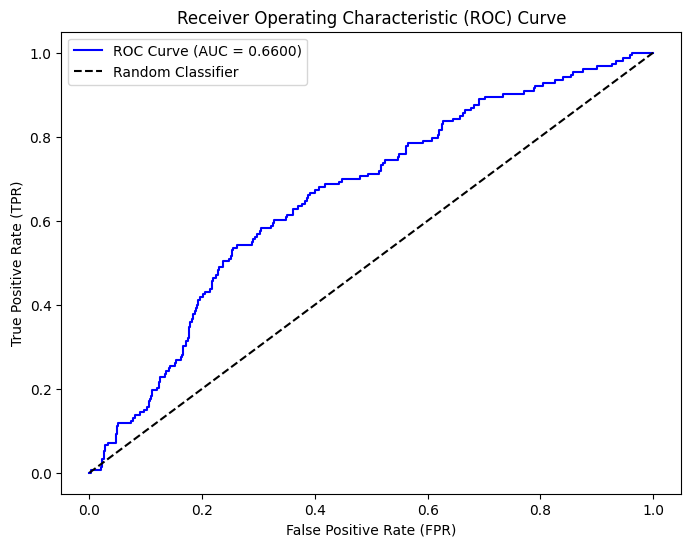

In [108]:
# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.4f})', color='blue')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')  # Diagonal line
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

In [109]:
from sklearn.ensemble import RandomForestClassifier

In [110]:
# Train the model
classifier = RandomForestClassifier(n_estimators=100, random_state=42)
classifier.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [111]:
# Predict and calculate AUC
y_pred_proba_classifier = classifier.predict_proba(X_test_scaled)[:, 1]
auc = roc_auc_score(y_test, y_pred_proba_classifier)
print(f"AUC: {auc:.4f}")

AUC: 0.5861


In [112]:
# Compute ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_classifier)

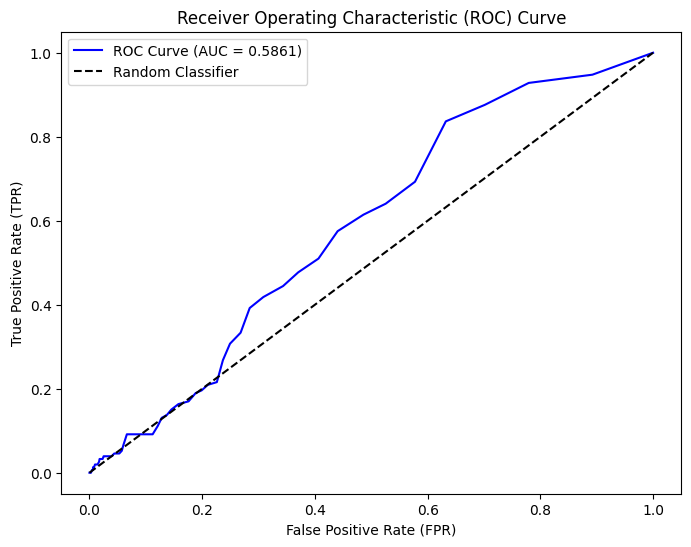

In [113]:
# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.4f})', color='blue')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')  # Diagonal line
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()